# Plant Growth Stage Classification — ResNet50 Fine-Tuning

Fine-tunes a pretrained ResNet50 (PyTorch/torchvision) to classify images into 4 growth stages: **seeding, developing, flowering, fruiting**.

Dataset layout expected:
```
dataset/
    seeding/    {train,valid,test}/*.jpg
    developing/ {train,valid,test}/*.jpg
    flowering/  {train,valid,test}/*.jpg
    fruiting/   {train,valid,test}/*.jpg
```
Update `DATA_DIR` in the Config cell below if your data lives elsewhere.

In [1]:
import os
import copy
import time
import random

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
# ---- Config ----
DATA_DIR = r"d:\Reasearch\Resnet50test\dataset"   # folder containing <class>/train, <class>/valid, <class>/test
CHECKPOINT_DIR = r"d:\Reasearch\Resnet50test\checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4
NUM_WORKERS = 4
FREEZE_BACKBONE = False  # True = only train the final classifier layer (faster, needs less data)

## 1. Data loading

Each class folder already contains its own pre-built `train/`, `valid/`, and `test/` subfolders
(`dataset/<class>/train|valid|test/`). We load these as three **separate** datasets instead of
pooling everything and re-splitting randomly, so the on-disk test set stays genuinely held out
and is never seen during training or model selection. Train images get augmentation; valid/test
images only get resize + normalize.

In [3]:
# ImageNet normalization stats (required since we use ImageNet-pretrained weights)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(int(IMAGE_SIZE * 1.14)),
    transforms.CenterCrop(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# SplitFolderDataset lives in dataset_utils.py (not defined here) so Windows
# DataLoader worker subprocesses (num_workers>0) can import/pickle it.
from dataset_utils import SplitFolderDataset

train_ds = SplitFolderDataset(DATA_DIR, "train", train_transform)
class_names = train_ds.classes
num_classes = len(class_names)
val_ds = SplitFolderDataset(DATA_DIR, "valid", eval_transform, classes=class_names)
test_ds = SplitFolderDataset(DATA_DIR, "test", eval_transform, classes=class_names)

print("Classes:", class_names)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"Train: {len(train_ds)} images | Val: {len(val_ds)} images | Test: {len(test_ds)} images")

Classes: ['developing', 'flowering', 'fruiting', 'seeding']
Train: 687 images | Val: 135 images | Test: 160 images


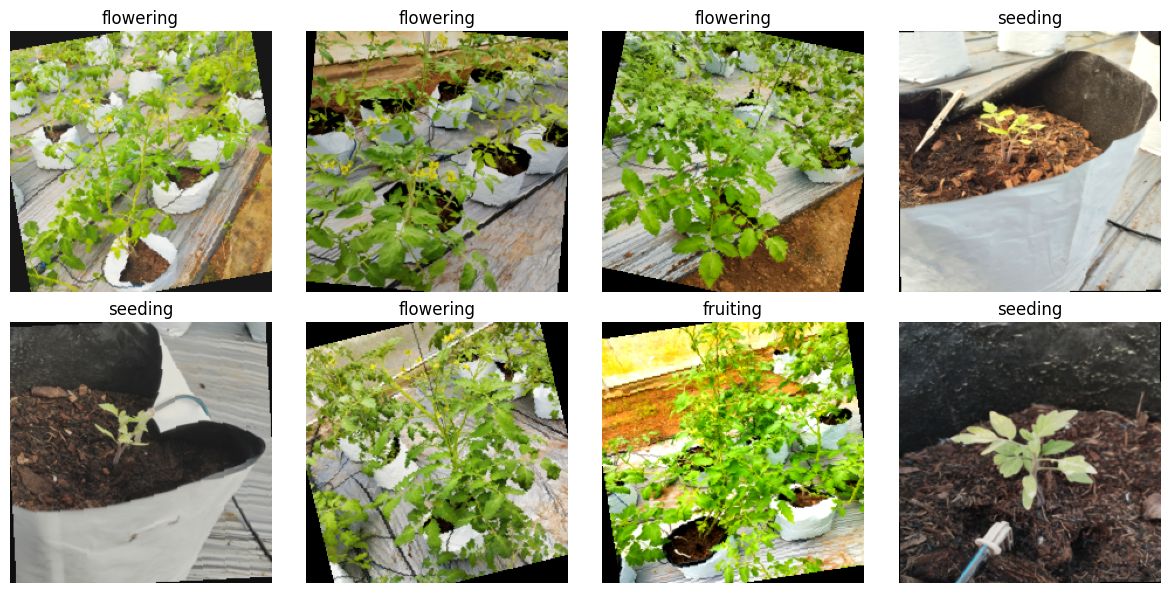

In [4]:
# Sanity-check a batch of training images
def denormalize(img_tensor):
    img = img_tensor.numpy().transpose(1, 2, 0)
    img = img * np.array(IMAGENET_STD) + np.array(IMAGENET_MEAN)
    return np.clip(img, 0, 1)

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(denormalize(images[i]))
    ax.set_title(class_names[labels[i]])
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Model — ResNet50 with a new classifier head

Loads ImageNet-pretrained ResNet50 and replaces the final fully-connected layer to output `num_classes` (4) instead of 1000. Set `FREEZE_BACKBONE = True` in the config cell to only train the new head (fast, good for small datasets); leave `False` to fine-tune the whole network.

In [5]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

if FREEZE_BACKBONE:
    for param in model.parameters():
        param.requires_grad = False

# Replace the final layer for our number of classes (this new layer is always trainable)
in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
params_to_update = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(params_to_update, lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

print(f"Trainable params: {sum(p.numel() for p in params_to_update):,}")

Trainable params: 23,516,228


## 3. Training loop

Trains for `NUM_EPOCHS`, tracks train/val loss and accuracy each epoch, saves the checkpoint with the best validation accuracy.

In [6]:
def run_epoch(model, loader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    running_loss, running_correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(dim=1)
            running_loss += loss.item() * inputs.size(0)
            running_correct += (preds == labels).sum().item()
            total += inputs.size(0)

    return running_loss / total, running_correct / total

In [7]:
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
best_ckpt_path = os.path.join(CHECKPOINT_DIR, "resnet50_best.pt")

start = time.time()
for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model, val_loader, criterion, optimizer=None)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save({
            "model_state_dict": best_model_wts,
            "class_names": class_names,
            "epoch": epoch,
            "val_acc": val_acc,
        }, best_ckpt_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
          f"val_loss {val_loss:.4f} val_acc {val_acc:.4f}")

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed // 60:.0f}m {elapsed % 60:.0f}s")
print(f"Best val accuracy: {best_val_acc:.4f} (saved to {best_ckpt_path})")

model.load_state_dict(best_model_wts)

Epoch 01/20 | train_loss 0.9873 train_acc 0.6696 | val_loss 0.4360 val_acc 0.9037
Epoch 02/20 | train_loss 0.4043 train_acc 0.8574 | val_loss 0.2035 val_acc 0.8963
Epoch 03/20 | train_loss 0.2317 train_acc 0.9127 | val_loss 0.2180 val_acc 0.9407
Epoch 04/20 | train_loss 0.1839 train_acc 0.9156 | val_loss 0.1323 val_acc 0.9333
Epoch 05/20 | train_loss 0.1302 train_acc 0.9534 | val_loss 0.1091 val_acc 0.9481
Epoch 06/20 | train_loss 0.0762 train_acc 0.9782 | val_loss 0.1787 val_acc 0.9333
Epoch 07/20 | train_loss 0.0655 train_acc 0.9753 | val_loss 0.0971 val_acc 0.9556
Epoch 08/20 | train_loss 0.0656 train_acc 0.9811 | val_loss 0.2689 val_acc 0.9333
Epoch 09/20 | train_loss 0.0622 train_acc 0.9840 | val_loss 0.1821 val_acc 0.9556
Epoch 10/20 | train_loss 0.0312 train_acc 0.9927 | val_loss 0.2184 val_acc 0.9259
Epoch 11/20 | train_loss 0.0335 train_acc 0.9898 | val_loss 0.1467 val_acc 0.9556
Epoch 12/20 | train_loss 0.0381 train_acc 0.9869 | val_loss 0.1542 val_acc 0.9556
Epoch 13/20 | tr

<All keys matched successfully>

## 4. Training curves

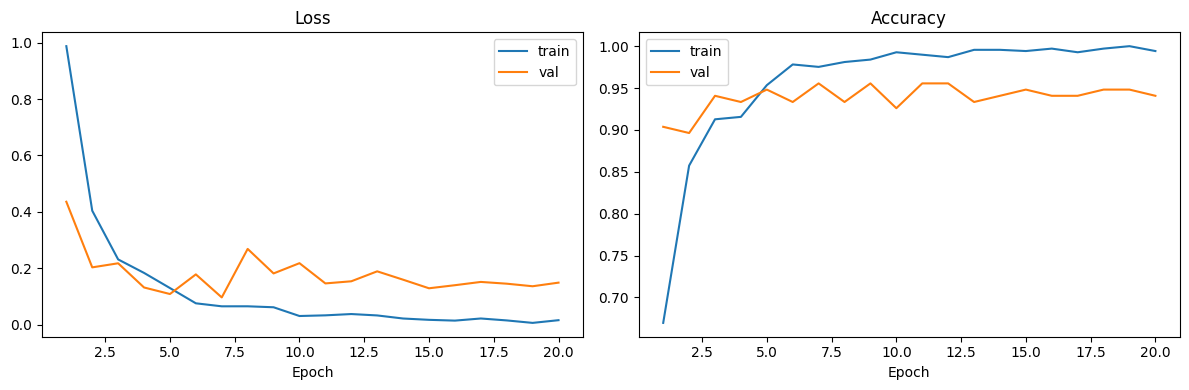

In [8]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_range, history["train_loss"], label="train")
axes[0].plot(epochs_range, history["val_loss"], label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(epochs_range, history["train_acc"], label="train")
axes[1].plot(epochs_range, history["val_acc"], label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Evaluation — confusion matrix & classification report

Runs the best checkpoint over the **held-out test set** (never seen during training or model
selection) and reports per-class precision/recall/F1.

Test accuracy: 0.9313

              precision    recall  f1-score   support

  developing       0.93      1.00      0.96        41
   flowering       0.90      0.92      0.91        60
    fruiting       0.88      0.71      0.79        21
     seeding       1.00      1.00      1.00        38

    accuracy                           0.93       160
   macro avg       0.93      0.91      0.92       160
weighted avg       0.93      0.93      0.93       160



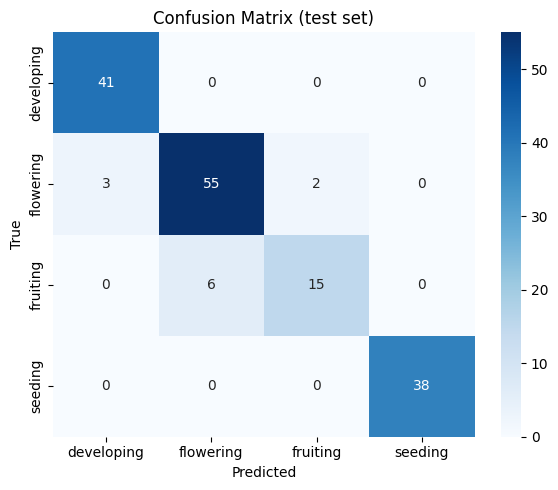

In [10]:
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy() if hasattr(labels, "numpy") else labels)

test_acc = (np.array(all_preds) == np.array(all_labels)).mean()
print(f"Test accuracy: {test_acc:.4f}\n")
print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (test set)")
plt.tight_layout()
plt.show()

## 6. Inference on a single image

Loads the saved checkpoint and predicts the growth stage for any image path.

In [11]:
from PIL import Image

def predict_image(image_path, ckpt_path=best_ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device)
    infer_model = models.resnet50(weights=None)
    infer_model.fc = nn.Linear(infer_model.fc.in_features, len(ckpt["class_names"]))
    infer_model.load_state_dict(ckpt["model_state_dict"])
    infer_model = infer_model.to(device).eval()

    img = Image.open(image_path).convert("RGB")
    tensor = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = infer_model(tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_idx = int(probs.argmax())
    print(f"Predicted: {ckpt['class_names'][pred_idx]} ({probs[pred_idx]*100:.1f}% confidence)")
    for cls, p in sorted(zip(ckpt["class_names"], probs), key=lambda x: -x[1]):
        print(f"  {cls:12s} {p*100:5.1f}%")

    plt.imshow(img)
    plt.axis("off")
    plt.title(ckpt["class_names"][pred_idx])
    plt.show()

# Example usage:
# predict_image(r"d:\Reasearch\Resnet50test\dataset\flowering\some_image.jpg")

In [12]:
# ==== Final Train / Val / Test accuracy summary (best checkpoint) ====
print("=" * 60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 60)

def eval_loader_clean(loader):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
            correct += (preds == labels.numpy()).sum()
            total += len(labels)
    return correct / total, np.array(all_preds), np.array(all_labels)

# Build a non-augmented version of the train set for a clean (no random-crop/flip/jitter) accuracy read
train_eval_ds = SplitFolderDataset(DATA_DIR, "train", eval_transform, classes=class_names)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

train_acc_clean, _, _ = eval_loader_clean(train_eval_loader)
val_acc_clean, val_preds, val_labels = eval_loader_clean(val_loader)
test_acc_clean, test_preds, test_labels = eval_loader_clean(test_loader)

print(f"\nBest checkpoint: epoch {best_epoch if 'best_epoch' in dir() else '(see best_ckpt_path)'}  |  saved val_acc during training: {best_val_acc:.4f}")
print(f"\nFresh evaluation (best checkpoint, no augmentation):")
print(f"  Train accuracy: {train_acc_clean:.4f}  ({len(train_eval_ds)} images)")
print(f"  Val accuracy:   {val_acc_clean:.4f}  ({len(val_ds)} images)")
print(f"  Test accuracy:  {test_acc_clean:.4f}  ({len(test_ds)} images)")

if train_acc_clean - test_acc_clean > 0.10:
    print("\n⚠️  Train-test gap > 10% — possible overfitting, worth investigating.")

FINAL MODEL PERFORMANCE SUMMARY

Best checkpoint: epoch (see best_ckpt_path)  |  saved val_acc during training: 0.9556

Fresh evaluation (best checkpoint, no augmentation):
  Train accuracy: 0.9782  (687 images)
  Val accuracy:   0.9556  (135 images)
  Test accuracy:  0.9313  (160 images)


In [1]:
# ==== K-Fold Cross-Validation (train+val pooled; test set untouched) ====
from sklearn.model_selection import StratifiedKFold
from PIL import Image

K_FOLDS = 5

# NOTE: assumes SplitFolderDataset exposes .samples as a list of (path, label) tuples,
# matching torchvision's ImageFolder convention. Adjust the attribute name below if
# your dataset_utils.py implementation differs.
combined_samples = train_ds.samples + val_ds.samples
combined_paths = [s[0] for s in combined_samples]
combined_labels = [s[1] for s in combined_samples]

class PathListDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, transform):
        self.paths, self.labels, self.transform = paths, labels, transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), self.labels[idx]

skf = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=SEED)
fold_accs = []

print(f"Running {K_FOLDS}-fold cross-validation on {len(combined_paths)} pooled train+val images...")
print("(test set is NOT used here — it stays held out for the final report)\n")

for fold, (tr_idx, va_idx) in enumerate(skf.split(combined_paths, combined_labels), 1):
    fold_train_ds = PathListDataset([combined_paths[i] for i in tr_idx], [combined_labels[i] for i in tr_idx], train_transform)
    fold_val_ds   = PathListDataset([combined_paths[i] for i in va_idx], [combined_labels[i] for i in va_idx], eval_transform)

    fold_train_loader = DataLoader(fold_train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    fold_val_loader   = DataLoader(fold_val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    fold_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    fold_model.fc = nn.Linear(fold_model.fc.in_features, num_classes)
    fold_model = fold_model.to(device)

    fold_optimizer = optim.Adam(fold_model.parameters(), lr=LEARNING_RATE)
    fold_criterion = nn.CrossEntropyLoss()

    best_fold_acc = 0.0
    for epoch in range(1, NUM_EPOCHS + 1):
        run_epoch(fold_model, fold_train_loader, fold_criterion, fold_optimizer)
        _, epoch_val_acc = run_epoch(fold_model, fold_val_loader, fold_criterion, optimizer=None)
        best_fold_acc = max(best_fold_acc, epoch_val_acc)

    print(f"Fold {fold}/{K_FOLDS}: best val accuracy = {best_fold_acc:.4f}")
    fold_accs.append(best_fold_acc)

fold_accs = np.array(fold_accs)
print("\n" + "=" * 60)
print(f"{K_FOLDS}-FOLD CROSS-VALIDATION RESULTS")
print("=" * 60)
print(f"  Per-fold accuracy: {[f'{a:.4f}' for a in fold_accs]}")
print(f"  Mean accuracy:     {fold_accs.mean():.4f}")
print(f"  Std deviation:     {fold_accs.std():.4f}")
print(f"  95% CI (approx):   [{fold_accs.mean() - 1.96*fold_accs.std()/np.sqrt(K_FOLDS):.4f}, "
      f"{fold_accs.mean() + 1.96*fold_accs.std()/np.sqrt(K_FOLDS):.4f}]")

NameError: name 'train_ds' is not defined